# A06 — So sánh PyTorch RNN và Keras SimpleRNN

Notebook cuối tổng hợp **chỉ các artifact thật đã được tạo ở Notebook 04–07**. Không model nào được khởi tạo, nạp checkpoint hoặc huấn luyện lại tại đây.

Hai bài toán được xem riêng:

1. Customer: 8 tuần × 5 feature → mua hàng tuần kế tiếp (binary classification).
2. Stock: 30 ngày × 5 feature → `Close` ngày kế tiếp (regression), kèm naive baseline `next Close = last Close`.

Mục tiêu là đối chiếu công bằng, giải thích khác biệt thực tế và nêu giới hạn; không lựa chọn “framework tốt nhất” chỉ từ một lần chạy.

## 1. Nguồn artifact và nguyên tắc kiểm tra

Notebook đọc bốn metrics JSON, `preprocessing_metadata.json` và bốn prediction CSV. Các metric được tính lại từ CSV rồi so với JSON. Checksum được kiểm tra khi source JSON có lưu checksum; mọi cặp framework phải mô tả cùng quan sát TEST trước khi so sánh.

In [1]:
from pathlib import Path
import hashlib
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.framework_comparison import (
    build_customer_metric_table,
    build_stock_metric_table,
    classification_metrics_from_predictions,
    regression_metrics_from_predictions,
    validate_customer_prediction_alignment,
    validate_stock_prediction_alignment,
)

METRICS_DIR = ROOT / "results" / "metrics"
PREDICTIONS_DIR = ROOT / "results" / "predictions"
FIGURE_DIR = ROOT / "results" / "figures" / "comparison"
SUMMARY_PATH = METRICS_DIR / "framework_comparison.json"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

METRIC_PATHS = {
    "pytorch_customer": METRICS_DIR / "pytorch_customer_metrics.json",
    "keras_customer": METRICS_DIR / "keras_customer_metrics.json",
    "pytorch_stock": METRICS_DIR / "pytorch_stock_metrics.json",
    "keras_stock": METRICS_DIR / "keras_stock_metrics.json",
    "preprocessing": METRICS_DIR / "preprocessing_metadata.json",
}

def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()

metrics = {
    name: json.loads(path.read_text(encoding="utf-8"))
    for name, path in METRIC_PATHS.items()
}
metric_hashes = {name: sha256(path) for name, path in METRIC_PATHS.items()}
print("Đã nạp:", ", ".join(path.name for path in METRIC_PATHS.values()))
print("Notebook này không chứa bước huấn luyện hoặc chọn lại model.")

Đã nạp: pytorch_customer_metrics.json, keras_customer_metrics.json, pytorch_stock_metrics.json, keras_stock_metrics.json, preprocessing_metadata.json
Notebook này không chứa bước huấn luyện hoặc chọn lại model.


## 2. Nạp và xác minh prediction CSV

Customer phải trùng `CustomerID`, `target_week`, `true_label`. Stock phải trùng `target_date`, `actual_close`, `naive_close`. Đây là điều kiện tiên quyết để chênh lệch metric phản ánh model thay vì lệch mẫu.

In [2]:
prediction_paths = {
    "pytorch_customer": PREDICTIONS_DIR / "pytorch_customer_predictions.csv",
    "keras_customer": PREDICTIONS_DIR / "keras_customer_predictions.csv",
    "pytorch_stock": PREDICTIONS_DIR / "pytorch_stock_predictions.csv",
    "keras_stock": PREDICTIONS_DIR / "keras_stock_predictions.csv",
}
predictions = {name: pd.read_csv(path) for name, path in prediction_paths.items()}
prediction_hashes = {name: sha256(path) for name, path in prediction_paths.items()}

validate_customer_prediction_alignment(
    predictions["pytorch_customer"], predictions["keras_customer"]
)
validate_stock_prediction_alignment(
    predictions["pytorch_stock"], predictions["keras_stock"]
)

# Kiểm tra checksum CSV đã được lưu ở các notebook nguồn khi có sẵn.
assert prediction_hashes["pytorch_customer"] == metrics["pytorch_customer"]["artifacts"]["predictions"]["sha256"]
assert prediction_hashes["keras_customer"] == metrics["keras_customer"]["artifacts"]["predictions"]["sha256"]
assert prediction_hashes["keras_stock"] == metrics["keras_stock"]["predictions"]["sha256"]

# Kiểm tra cả bốn thí nghiệm dùng source preprocessing đã khóa.
preprocessing = metrics["preprocessing"]
for framework in ("pytorch_customer", "keras_customer"):
    assert metrics[framework]["data"]["source_artifacts"] == preprocessing["customer"]["artifacts"]
for framework in ("pytorch_stock", "keras_stock"):
    assert metrics[framework]["input_artifact_sha256"] == {
        split: preprocessing["stock"]["artifacts"][split]["sha256"]
        for split in ("train", "val", "test")
    }

audit_table = pd.DataFrame(
    [
        {"artifact": name, "rows": len(frame), "columns": len(frame.columns), "sha256": prediction_hashes[name][:12] + "…"}
        for name, frame in predictions.items()
    ]
).set_index("artifact")
audit_table

,rows,columns,sha256
artifact,,,
pytorch_customer,53052,5,39ef1e482e1d…
keras_customer,53052,5,63fabc48e5c3…
pytorch_stock,410,4,65118b2c00ef…
keras_stock,410,4,1e044a298c17…


Kết quả audit: hai customer file cùng 53.052 quan sát TEST; hai stock file cùng 410 ngày TEST. Naive prediction stock trùng tuyệt đối ở mọi dòng, nên baseline chỉ xuất hiện một lần trong bảng so sánh.

# Phần A — Customer classification

## 3. Bảng metric và metadata huấn luyện

Hai model dùng cùng input `(8, 5)`, class weight TRAIN-only `14.2263`, threshold `0.5` và cùng TEST. Metrics dưới đây được đọc từ JSON và được đối chiếu lại từ probability CSV.

In [3]:
customer_table = build_customer_metric_table(
    metrics["pytorch_customer"], metrics["keras_customer"]
)

for name in ("pytorch_customer", "keras_customer"):
    recalculated = classification_metrics_from_predictions(predictions[name], threshold=0.5)
    stored = metrics[name]["evaluation"]["metrics"]
    for metric_name, value in recalculated.items():
        assert np.isclose(value, stored[metric_name], rtol=0, atol=1e-12)

customer_display = customer_table.copy()
for column in ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]:
    customer_display[column] = customer_display[column].map(lambda value: f"{value:.4f}")
customer_display["Parameters"] = customer_display["Parameters"].map(lambda value: f"{int(value):,}")
customer_display["Epochs"] = customer_display["Epochs"].astype(int)
customer_display["Training seconds"] = customer_display["Training seconds"].map(lambda value: f"{value:.2f}")
customer_display

,Accuracy,Precision,Recall,F1-score,ROC-AUC,Parameters,Epochs,Training seconds,Device
Model,,,,,,,,,
PyTorch RNN,0.7582,0.1587,0.5722,0.2485,0.7009,"4,609",11,151.06,cpu
Keras SimpleRNN,0.7600,0.1594,0.5697,0.2491,0.7005,"4,545",18,86.01,cpu


### Phân tích kết quả customer

- Các metric gần như trùng nhau: ROC-AUC là `0.7009` (PyTorch) và `0.7005` (Keras); F1 là `0.2485` và `0.2491`.
- Keras có Accuracy/Precision/F1 cao hơn rất nhẹ; PyTorch có Recall/ROC-AUC cao hơn rất nhẹ. Chênh lệch đều nhỏ hơn 0,25 điểm phần trăm tuyệt đối và không đủ để tuyên bố một framework thắng tổng quát.
- Precision thấp (`~0.159`) phản ánh nhiều false positive khi dùng class weighting để ưu tiên tìm lớp mua hàng hiếm. Recall khoảng `0.57`, cao hơn tỷ lệ bắt được nếu model chỉ dự đoán lớp 0.
- PyTorch có 4.609 tham số, Keras 4.545 do cách triển khai bias RNN khác nhau; cả hai vẫn là một recurrent layer 64 hidden units.
- Thời gian training 22,51 giây so với 17,56 giây chỉ mô tả lần chạy CPU này. Khác biệt framework runtime, kernel, graph/eager execution, callback và số epoch làm nó **không phải benchmark phổ quát**.

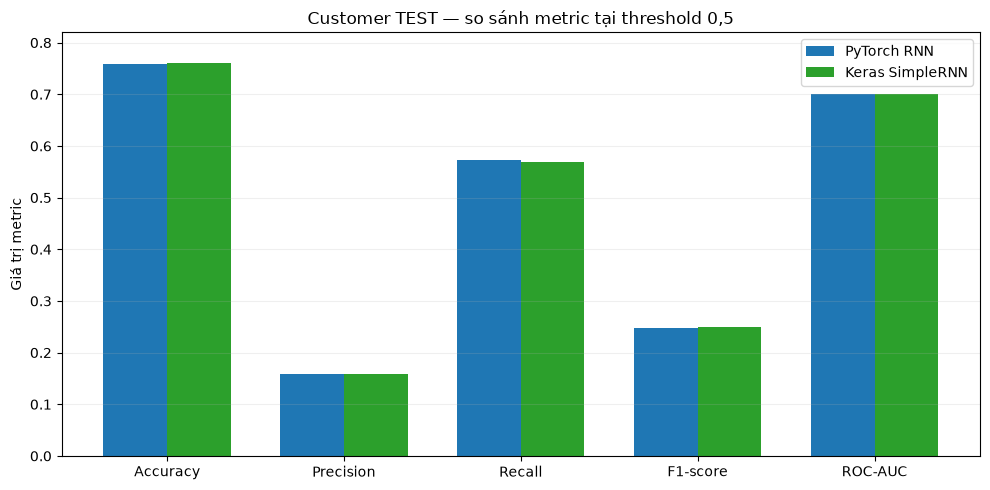

In [4]:
metric_names = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
x = np.arange(len(metric_names))
width = 0.36
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width / 2, customer_table.loc["PyTorch RNN", metric_names], width, label="PyTorch RNN", color="#1f77b4")
ax.bar(x + width / 2, customer_table.loc["Keras SimpleRNN", metric_names], width, label="Keras SimpleRNN", color="#2ca02c")
ax.set_xticks(x, metric_names)
ax.set_ylim(0, 0.82)
ax.set_ylabel("Giá trị metric")
ax.set_title("Customer TEST — so sánh metric tại threshold 0,5")
ax.grid(axis="y", alpha=0.2)
ax.legend()
fig.tight_layout()
customer_metrics_figure = FIGURE_DIR / "customer_metrics_comparison.png"
fig.savefig(customer_metrics_figure, dpi=160, bbox_inches="tight")
plt.show()

## 4. Confusion matrices

Keras tạo ít dự đoán dương hơn một chút: so với PyTorch, Keras có thêm 109 TN, bớt 109 FP, nhưng bớt 9 TP và thêm 9 FN. Đây là trade-off rất nhỏ giữa Precision/Accuracy và Recall, không phải bằng chứng về ưu thế framework.

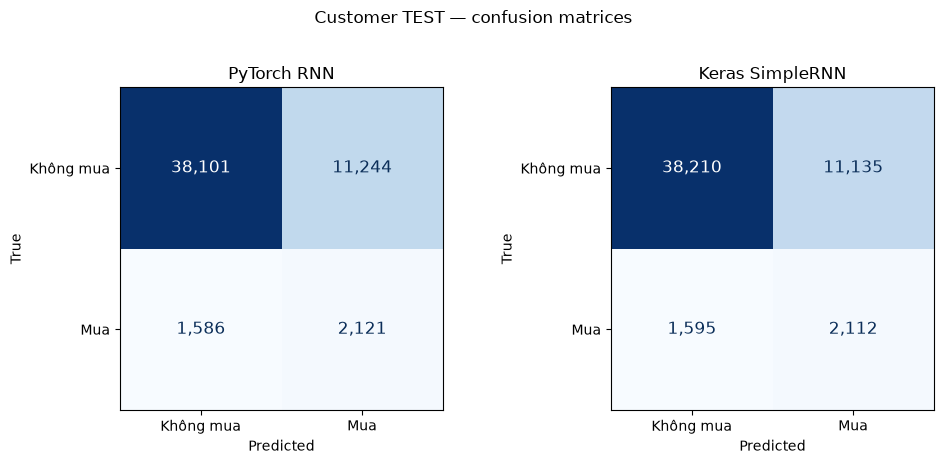

In [5]:
customer_confusions = {}
for name, label in (("pytorch_customer", "PyTorch RNN"), ("keras_customer", "Keras SimpleRNN")):
    frame = predictions[name]
    matrix = confusion_matrix(frame["true_label"], frame["predicted_label"], labels=[0, 1])
    stored = metrics[name]["evaluation"]["confusion_matrix_tn_fp_fn_tp"]
    assert matrix.ravel().tolist() == [stored["tn"], stored["fp"], stored["fn"], stored["tp"]]
    customer_confusions[label] = matrix

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, (label, matrix) in zip(axes, customer_confusions.items()):
    image = ax.imshow(matrix, cmap="Blues")
    for row in range(2):
        for column in range(2):
            threshold = matrix.max() / 2
            color = "white" if matrix[row, column] > threshold else "#0b2e59"
            ax.text(column, row, f"{matrix[row, column]:,}", ha="center", va="center", color=color, fontsize=12)
    ax.set_xticks([0, 1], ["Không mua", "Mua"])
    ax.set_yticks([0, 1], ["Không mua", "Mua"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(label)
fig.suptitle("Customer TEST — confusion matrices", y=1.02)
fig.tight_layout()
customer_confusion_figure = FIGURE_DIR / "customer_confusion_matrices.png"
fig.savefig(customer_confusion_figure, dpi=160, bbox_inches="tight")
plt.show()

## 5. ROC curves và hành vi probability

ROC curves gần như chồng lên nhau, phù hợp với chênh lệch AUC chỉ khoảng `0.00044`. Probability của hai model có correlation `0.9919` và nhãn tại threshold 0,5 đồng ý trên 99,25% mẫu. Điều đó cho thấy hai triển khai đã học hành vi xếp hạng rất giống nhau, dù calibration không hoàn toàn đồng nhất.

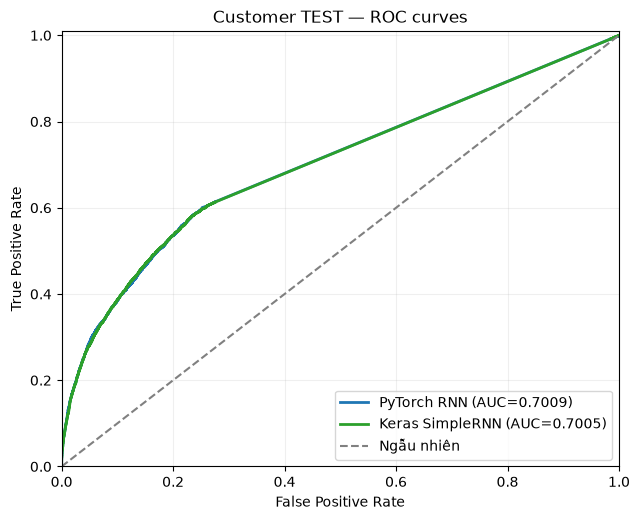

Probability correlation: 0.991862
Prediction agreement: 99.2536% (396 mẫu khác nhãn)


In [6]:
pt_customer = predictions["pytorch_customer"]
keras_customer = predictions["keras_customer"]
probability_correlation = float(pt_customer["probability"].corr(keras_customer["probability"]))
prediction_agreement = float((pt_customer["predicted_label"] == keras_customer["predicted_label"]).mean())
disagreement_count = int((pt_customer["predicted_label"] != keras_customer["predicted_label"]).sum())

fig, ax = plt.subplots(figsize=(6.5, 5.3))
for frame, label, color in (
    (pt_customer, "PyTorch RNN", "#1f77b4"),
    (keras_customer, "Keras SimpleRNN", "#2ca02c"),
):
    fpr, tpr, _ = roc_curve(frame["true_label"], frame["probability"])
    auc = classification_metrics_from_predictions(frame)["roc_auc"]
    ax.plot(fpr, tpr, linewidth=2, color=color, label=f"{label} (AUC={auc:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Ngẫu nhiên")
ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="Customer TEST — ROC curves")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.01)
ax.grid(alpha=0.2)
ax.legend(loc="lower right")
fig.tight_layout()
customer_roc_figure = FIGURE_DIR / "customer_roc_comparison.png"
fig.savefig(customer_roc_figure, dpi=160, bbox_inches="tight")
plt.show()

print(f"Probability correlation: {probability_correlation:.6f}")
print(f"Prediction agreement: {prediction_agreement:.4%} ({disagreement_count:,} mẫu khác nhãn)")

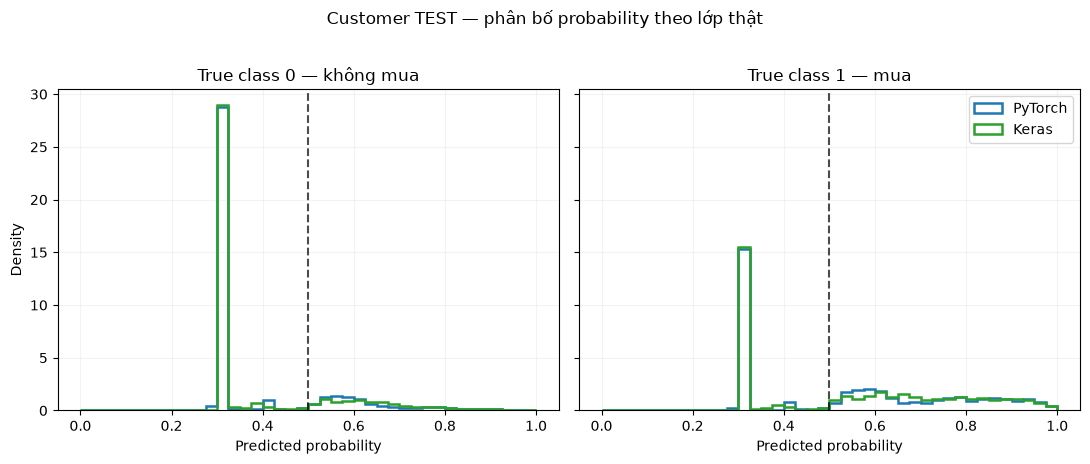

,PyTorch,Keras
count,53052.0000,53052.0000
mean,0.3972,0.4104
std,0.1588,0.1559
min,0.2810,0.2891
25%,0.3066,0.3226
50%,0.3066,0.3226
75%,0.5052,0.4990
max,0.9865,0.9894


In [7]:
probability_summary = pd.DataFrame(
    {
        "PyTorch": pt_customer["probability"].describe(percentiles=[0.25, 0.5, 0.75]),
        "Keras": keras_customer["probability"].describe(percentiles=[0.25, 0.5, 0.75]),
    }
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
bins = np.linspace(0, 1, 41)
for ax, true_label, title in zip(axes, [0, 1], ["True class 0 — không mua", "True class 1 — mua"]):
    for frame, label, color in (
        (pt_customer, "PyTorch", "#1f77b4"),
        (keras_customer, "Keras", "#2ca02c"),
    ):
        values = frame.loc[frame["true_label"] == true_label, "probability"]
        ax.hist(values, bins=bins, density=True, histtype="step", linewidth=1.8, label=label, color=color)
    ax.axvline(0.5, color="black", linestyle="--", alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("Predicted probability")
    ax.grid(alpha=0.15)
axes[0].set_ylabel("Density")
axes[1].legend()
fig.suptitle("Customer TEST — phân bố probability theo lớp thật", y=1.02)
fig.tight_layout()
customer_probability_figure = FIGURE_DIR / "customer_probability_behavior.png"
fig.savefig(customer_probability_figure, dpi=160, bbox_inches="tight")
plt.show()

probability_summary.round(4)

# Phần B — Stock regression

## 6. Bảng metric và xác minh naive baseline

Metric được tính trên giá `Close` thực sau inverse scaling. Baseline trong hai JSON và hai CSV giống nhau đến độ chính xác lưu trữ: cùng 410 ngày, cùng actual và cùng naive prediction. Vì vậy chỉ có một hàng naive hợp lệ.

In [8]:
stock_table = build_stock_metric_table(metrics["pytorch_stock"], metrics["keras_stock"])

for name in ("pytorch_stock", "keras_stock"):
    recalculated = regression_metrics_from_predictions(predictions[name], "predicted_close")
    stored = metrics[name]["test_metrics_real_scale"]
    for metric_name, value in recalculated.items():
        assert np.isclose(value, stored[metric_name], rtol=0, atol=1e-12)

pt_naive = regression_metrics_from_predictions(predictions["pytorch_stock"], "naive_close")
keras_naive = regression_metrics_from_predictions(predictions["keras_stock"], "naive_close")
for metric_name in pt_naive:
    assert np.isclose(pt_naive[metric_name], keras_naive[metric_name], rtol=0, atol=1e-12)

stock_table.round(4)

,MAE (USD),RMSE (USD),R²
Model,,,
PyTorch RNN,20.3393,23.5788,-0.0269
Keras SimpleRNN,23.1947,27.8703,-0.4347
Naive last Close,2.6177,3.8789,0.9722


### Phân tích kết quả stock

- PyTorch RNN có MAE/RMSE `20,34/23,58 USD`; Keras RNN là `23,19/27,87 USD`. Trong lần chạy này PyTorch có sai số thấp hơn Keras, nhưng một thí nghiệm không đủ để kết luận framework nói chung tốt hơn.
- R² của cả hai RNN âm (`-0,0269` và `-0,4347`), nghĩa là theo squared error chúng còn kém mốc dự đoán hằng bằng trung bình TEST.
- Naive đạt MAE `2,62 USD`, RMSE `3,88 USD`, R² `0,9722`, vượt xa cả hai RNN trên cùng mẫu. Câu trả lời thực nghiệm là rõ ràng: **Vanilla RNN không đánh bại naive stock baseline**.
- Cả hai RNN có thiên lệch dự đoán thấp hơn giá thật trong giai đoạn TEST tăng lên mức ngoài phần lớn range TRAIN. Đây là ví dụ về khó khăn khi dùng Vanilla RNN dự báo mức giá không dừng (non-stationary level).

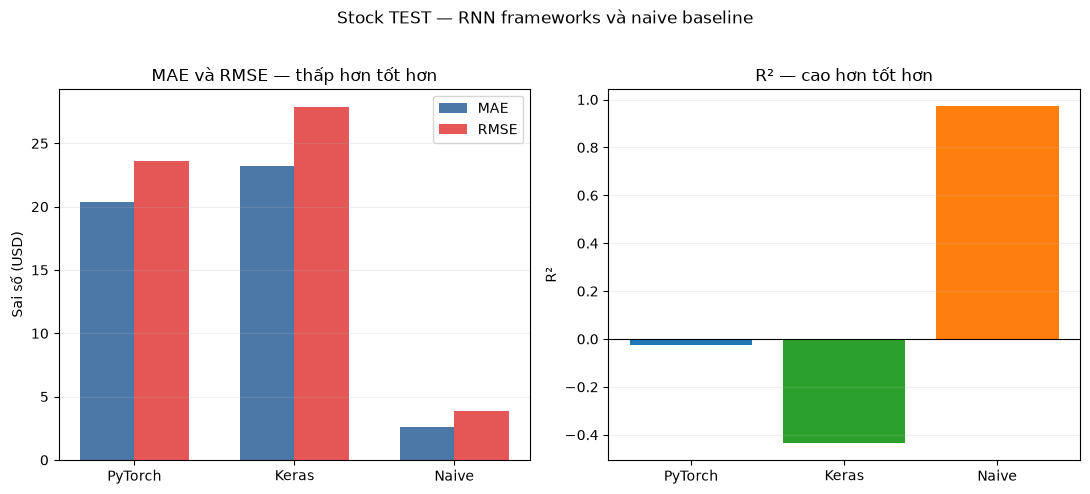

In [9]:
stock_colors = ["#1f77b4", "#2ca02c", "#ff7f0e"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

x = np.arange(len(stock_table))
width = 0.34
axes[0].bar(x - width / 2, stock_table["MAE (USD)"], width, label="MAE", color="#4c78a8")
axes[0].bar(x + width / 2, stock_table["RMSE (USD)"], width, label="RMSE", color="#e45756")
axes[0].set_xticks(x, ["PyTorch", "Keras", "Naive"])
axes[0].set_ylabel("Sai số (USD)")
axes[0].set_title("MAE và RMSE — thấp hơn tốt hơn")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.2)

axes[1].bar(["PyTorch", "Keras", "Naive"], stock_table["R²"], color=stock_colors)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("R²")
axes[1].set_title("R² — cao hơn tốt hơn")
axes[1].grid(axis="y", alpha=0.2)

fig.suptitle("Stock TEST — RNN frameworks và naive baseline", y=1.02)
fig.tight_layout()
stock_metrics_figure = FIGURE_DIR / "stock_metrics_comparison.png"
fig.savefig(stock_metrics_figure, dpi=160, bbox_inches="tight")
plt.show()

## 7. Actual-vs-predicted trên cùng timeline

Đồ thị dùng đúng `target_date` đã khóa. Naive bám sát actual vì nó dịch giá ngày trước sang ngày kế tiếp; hai RNN theo được một phần chuyển động nhưng co dự đoán về vùng giá thấp hơn, đặc biệt cuối TEST.

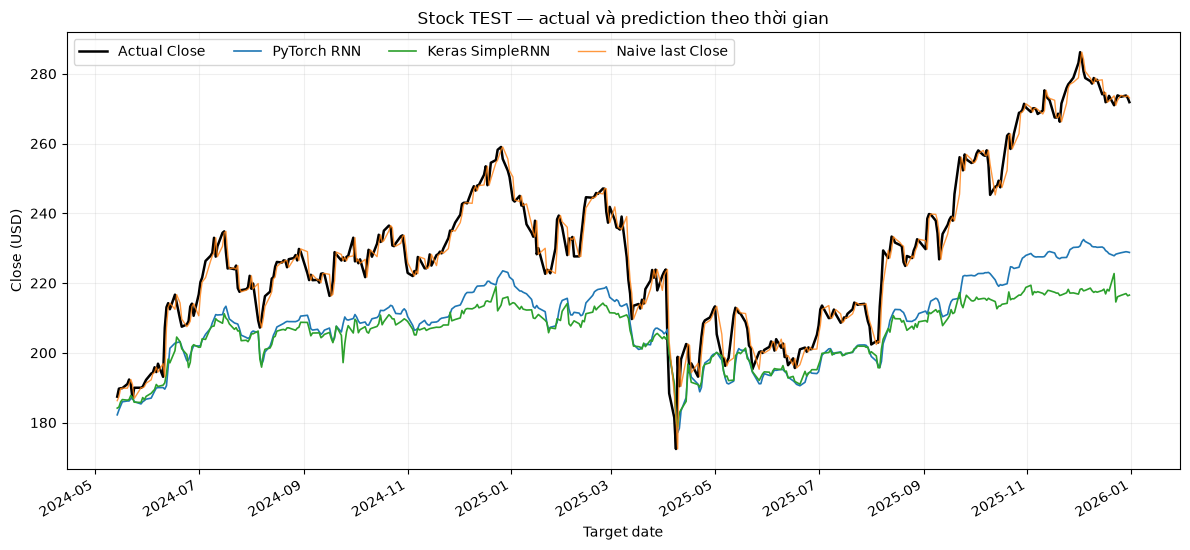

Mean error PyTorch: -20.16 USD
Mean error Keras: -23.03 USD


In [10]:
pt_stock = predictions["pytorch_stock"]
keras_stock = predictions["keras_stock"]
stock_dates = pd.to_datetime(pt_stock["target_date"])

stock_bias = {
    "pytorch_mean_error": float((pt_stock["predicted_close"] - pt_stock["actual_close"]).mean()),
    "keras_mean_error": float((keras_stock["predicted_close"] - keras_stock["actual_close"]).mean()),
}

fig, ax = plt.subplots(figsize=(12, 5.6))
ax.plot(stock_dates, pt_stock["actual_close"], color="black", linewidth=1.8, label="Actual Close")
ax.plot(stock_dates, pt_stock["predicted_close"], color="#1f77b4", linewidth=1.2, label="PyTorch RNN")
ax.plot(stock_dates, keras_stock["predicted_close"], color="#2ca02c", linewidth=1.2, label="Keras SimpleRNN")
ax.plot(stock_dates, pt_stock["naive_close"], color="#ff7f0e", linewidth=1.0, alpha=0.8, label="Naive last Close")
ax.set(title="Stock TEST — actual và prediction theo thời gian", xlabel="Target date", ylabel="Close (USD)")
ax.grid(alpha=0.2)
ax.legend(ncol=4)
fig.autofmt_xdate()
fig.tight_layout()
stock_prediction_figure = FIGURE_DIR / "stock_actual_vs_predicted.png"
fig.savefig(stock_prediction_figure, dpi=160, bbox_inches="tight")
plt.show()

print(f"Mean error PyTorch: {stock_bias['pytorch_mean_error']:.2f} USD")
print(f"Mean error Keras: {stock_bias['keras_mean_error']:.2f} USD")

# Phần C — Khác biệt thực hành giữa framework

## 8. PyTorch và Keras khác nhau ở đâu?

| Khía cạnh | PyTorch | Keras |
|---|---|---|
| Cấp dữ liệu | `Dataset` và `DataLoader`; kiểm soát batch/shuffle rõ ràng | Có thể truyền trực tiếp NumPy arrays cho `fit()` |
| Training loop | Viết rõ `zero_grad → forward → loss → backward → optimizer.step` | `model.fit()` đóng gói vòng lặp |
| Optimizer | Bước cập nhật được gọi thủ công | Được cấu hình trong `compile()` và chạy bởi `fit()` |
| Early stopping | Logic/checkpoint được triển khai rõ trong code | Dùng `EarlyStopping` và `ModelCheckpoint` callbacks |
| Device | Chuyển model/tensor bằng `.to(device)` | Runtime quản lý placement; vẫn phải kiểm tra thiết bị thực tế |
| Định nghĩa model | `nn.RNN` + `nn.Linear` | `SimpleRNN` + `Dense` |

PyTorch phơi bày nhiều chi tiết hơn, hữu ích khi cần training loop tùy chỉnh. Keras ngắn gọn hơn cho baseline chuẩn. **Ít dòng code không đồng nghĩa predictive quality cao hơn**; chất lượng phụ thuộc dữ liệu, objective, optimization, architecture và protocol đánh giá.

## 9. Giới hạn của Vanilla RNN

- **Temporal dependence:** RNN dùng hidden state để mang thông tin qua thời gian, nhưng hidden state hữu hạn phải nén toàn bộ lịch sử.
- **Vanishing gradient:** gradient nhân lặp qua nhiều time steps có thể nhỏ dần, làm tín hiệu xa khó ảnh hưởng trọng số.
- **Limited long-term memory:** Vanilla RNN không có cell state và gates chuyên dụng; với phụ thuộc dài, thông tin cũ dễ bị ghi đè.
- **Dữ liệu customer:** mất cân bằng mạnh và hành vi mua thưa khiến threshold 0,5 tạo nhiều false positive khi dùng class weighting.
- **Dữ liệu stock:** mức giá non-stationary, regime shift và thông tin ngoại sinh khiến dự báo exact price khó; mô hình học trên range cũ có thể co dự đoán khi TEST lên vùng giá mới.
- **Một split, một seed:** kết quả hiện tại là baseline có kiểm soát, không phải ước lượng đầy đủ về biến thiên qua nhiều giai đoạn hoặc nhiều seed.

LSTM và GRU có gates giúp duy trì/điều tiết memory và là hướng mở rộng hợp lý. Notebook này **không huấn luyện LSTM/GRU**, đúng phạm vi Vanilla RNN đã khóa.

## 10. Kết luận cuối

1. **Customer experiment chứng minh gì?** Hai Vanilla RNN học được tín hiệu xếp hạng ở mức vừa phải (`ROC-AUC ≈ 0,70`) và tìm được khoảng 57% lớp mua hàng, nhưng Precision chỉ khoảng 16% do dữ liệu mất cân bằng và nhiều false positive. Hai framework cho hành vi gần như giống nhau.
2. **Stock experiment chứng minh gì?** Cả hai RNN theo được một phần hình dạng chuỗi nhưng dự báo thấp đáng kể khi giá TEST vượt vùng lịch sử; real-scale error lớn và R² âm.
3. **Implementations khác nhau thế nào?** PyTorch dùng `Dataset`/`DataLoader`, explicit loop, optimizer step và device handling; Keras dùng model definition ngắn, `fit()` và callbacks. Đây là khác biệt về mức abstraction, không tự quyết định chất lượng dự báo.
4. **RNN có đánh bại naive stock baseline không?** **Không.** Naive RMSE `3,8789 USD`, thấp hơn nhiều so với PyTorch `23,5788 USD` và Keras `27,8703 USD`; baseline giống nhau tuyệt đối giữa hai artifact.
5. **Giới hạn là gì?** Vanilla RNN gặp vanishing gradient và memory dài hạn hạn chế; customer data mất cân bằng, stock data non-stationary và thiếu biến ngoại sinh; kết quả dựa trên một split/seed. LSTM/GRU, nhiều temporal folds, calibration/threshold analysis và target formulation khác là hướng nghiên cứu tiếp theo, không phải kết quả đã được chứng minh ở đây.

Không có khuyến nghị tài chính nào được đưa ra.

## 11. Lưu summary machine-readable và kiểm tra cuối

JSON tổng hợp giữ metric, kiểm tra alignment, probability behavior, bias stock, kết luận và checksum nguồn. Nó không chứa metric mới từ quá trình huấn luyện vì không có huấn luyện trong notebook này.

In [11]:
customer_deltas = {
    metric_name: float(customer_table.loc["Keras SimpleRNN", column] - customer_table.loc["PyTorch RNN", column])
    for metric_name, column in (
        ("accuracy", "Accuracy"),
        ("precision", "Precision"),
        ("recall", "Recall"),
        ("f1", "F1-score"),
        ("roc_auc", "ROC-AUC"),
    )
}

figure_paths = [
    customer_metrics_figure,
    customer_confusion_figure,
    customer_roc_figure,
    customer_probability_figure,
    stock_metrics_figure,
    stock_prediction_figure,
]

summary = {
    "schema_version": 1,
    "artifact_only_comparison": True,
    "retraining_performed": False,
    "source_metrics": {
        name: {"path": str(METRIC_PATHS[name].relative_to(ROOT)).replace("\\", "/"), "sha256": metric_hashes[name]}
        for name in METRIC_PATHS
    },
    "source_predictions": {
        name: {"path": str(prediction_paths[name].relative_to(ROOT)).replace("\\", "/"), "sha256": prediction_hashes[name], "rows": len(predictions[name])}
        for name in prediction_paths
    },
    "preprocessing_contract": {
        "seed": preprocessing["seed"],
        "customer_sequence_length": preprocessing["customer"]["sequence_length"],
        "customer_features": preprocessing["customer"]["feature_names"],
        "customer_test_shape": preprocessing["customer"]["splits"]["test"]["X_shape"],
        "stock_sequence_length": preprocessing["stock"]["sequence_length"],
        "stock_features": preprocessing["stock"]["feature_names"],
        "stock_test_shape": preprocessing["stock"]["splits"]["test"]["X_shape"],
        "stock_target_scaler_sha256": preprocessing["stock"]["target_scaler"]["sha256"],
    },
    "customer": {
        "same_test_keys_and_labels_verified": True,
        "threshold": 0.5,
        "models": {
            model: {
                "metrics": {
                    "accuracy": float(row["Accuracy"]),
                    "precision": float(row["Precision"]),
                    "recall": float(row["Recall"]),
                    "f1": float(row["F1-score"]),
                    "roc_auc": float(row["ROC-AUC"]),
                },
                "parameter_count": int(row["Parameters"]),
                "epochs_actually_run": int(row["Epochs"]),
                "training_duration_seconds": float(row["Training seconds"]),
                "device": row["Device"],
                "confusion_matrix_tn_fp_fn_tp": {
                    "tn": int(customer_confusions[model][0, 0]),
                    "fp": int(customer_confusions[model][0, 1]),
                    "fn": int(customer_confusions[model][1, 0]),
                    "tp": int(customer_confusions[model][1, 1]),
                },
            }
            for model, row in customer_table.iterrows()
        },
        "keras_minus_pytorch_metric_delta": customer_deltas,
        "probability_correlation": probability_correlation,
        "prediction_agreement_rate": prediction_agreement,
        "prediction_disagreement_count": disagreement_count,
        "interpretation": "Very similar ranking and threshold behavior; small metric trade-offs do not establish a universal framework winner.",
        "training_duration_note": "Descriptive for this CPU run; framework implementation, runtime, callbacks, and epochs affect timing.",
    },
    "stock": {
        "same_dates_actual_and_naive_verified": True,
        "baseline_values_identical_between_framework_csvs": True,
        "models": {
            model: {
                "mae": float(row["MAE (USD)"]),
                "rmse": float(row["RMSE (USD)"]),
                "r2": float(row["R²"]),
            }
            for model, row in stock_table.iterrows()
        },
        "mean_prediction_error_usd": stock_bias,
        "rnn_beats_naive_baseline": False,
        "interpretation": "Naive last-Close decisively outperformed both Vanilla RNNs on the identical TEST samples.",
    },
    "framework_practice": {
        "pytorch": ["Dataset/DataLoader", "explicit training loop", "manual optimizer steps", "explicit device handling"],
        "keras": ["NumPy input to model.fit()", "callbacks", "higher-level training API", "concise model definition"],
        "caveat": "Fewer lines of code do not imply better predictive quality.",
    },
    "limitations": [
        "Vanilla RNN vanishing gradients and limited long-term memory",
        "strong customer class imbalance",
        "non-stationary stock price level and omitted exogenous information",
        "single chronological split and single seed",
        "LSTM/GRU are future extensions and were not trained here",
    ],
    "figures": [str(path.relative_to(ROOT)).replace("\\", "/") for path in figure_paths],
}
SUMMARY_PATH.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

assert summary["retraining_performed"] is False
assert summary["stock"]["rnn_beats_naive_baseline"] is False
assert SUMMARY_PATH.is_file()
assert all(path.is_file() for path in figure_paths)
print(f"Đã lưu summary -> {SUMMARY_PATH.relative_to(ROOT)}")
print("PASS — comparison chỉ dùng artifact thật; alignment, metrics và baseline đã được xác minh.")

Đã lưu summary -> results\metrics\framework_comparison.json
PASS — comparison chỉ dùng artifact thật; alignment, metrics và baseline đã được xác minh.
